# Differential gene expression over updated cell-types

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
    library(SingleCellExperiment)
    library(scater)
    library(scran)
    library(edgeR)
    library(ggrastr)
})

here::i_am("differential/Differential_expression.ipynb")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/code



In [2]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/"

In [3]:
args = list()
args$sce = io$rna.sce
args$metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/results/rna/mapping/sample_metadata_after_mapping.txt.gz'
args$variable = 'celltype.mapped_mnn'
args$outdir = paste0(io$basedir,"/results/rna/differential/manual")
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

In [4]:
# Functions
# Plotting function
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=20, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = de.results[variable == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
               .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*1.05), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim*1.16)) +
    annotate("text", x=0, y=ylim*1.1, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=gene), 
                                     max.overlaps=Inf, 
                                     box.padding = 0.5,
                                     bg.color='white', 
                                     bg.r = 0.1,
                                     size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
    
    
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

In [5]:
###############
## Load data ##
###############

# Load metadata
sample_metadata <- fread(args$metadata) %>%
    .[!is.na(celltype.mapped_mnn)] %>%
   .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)] %>% 
   .[,variable := .[[args$variable]]]

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [6]:
nrow(sample_metadata)

[1] 19386

In [7]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(sce, 
    id=colData(sce)[,c("variable", "sample", "tdTom")])

summed.filt <- summed[,summed$ncells >= 20]

In [8]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(summed.filt, 
    label=summed.filt$variable,
    design=~factor(pool) + tdTom,
    lfc = 0.5,
    coef="tdTomTRUE",
    condition=summed.filt$tdTom
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [9]:
fwrite(de.results, file.path(args$outdir, 'pseudoBulkAll.txt.gz'))

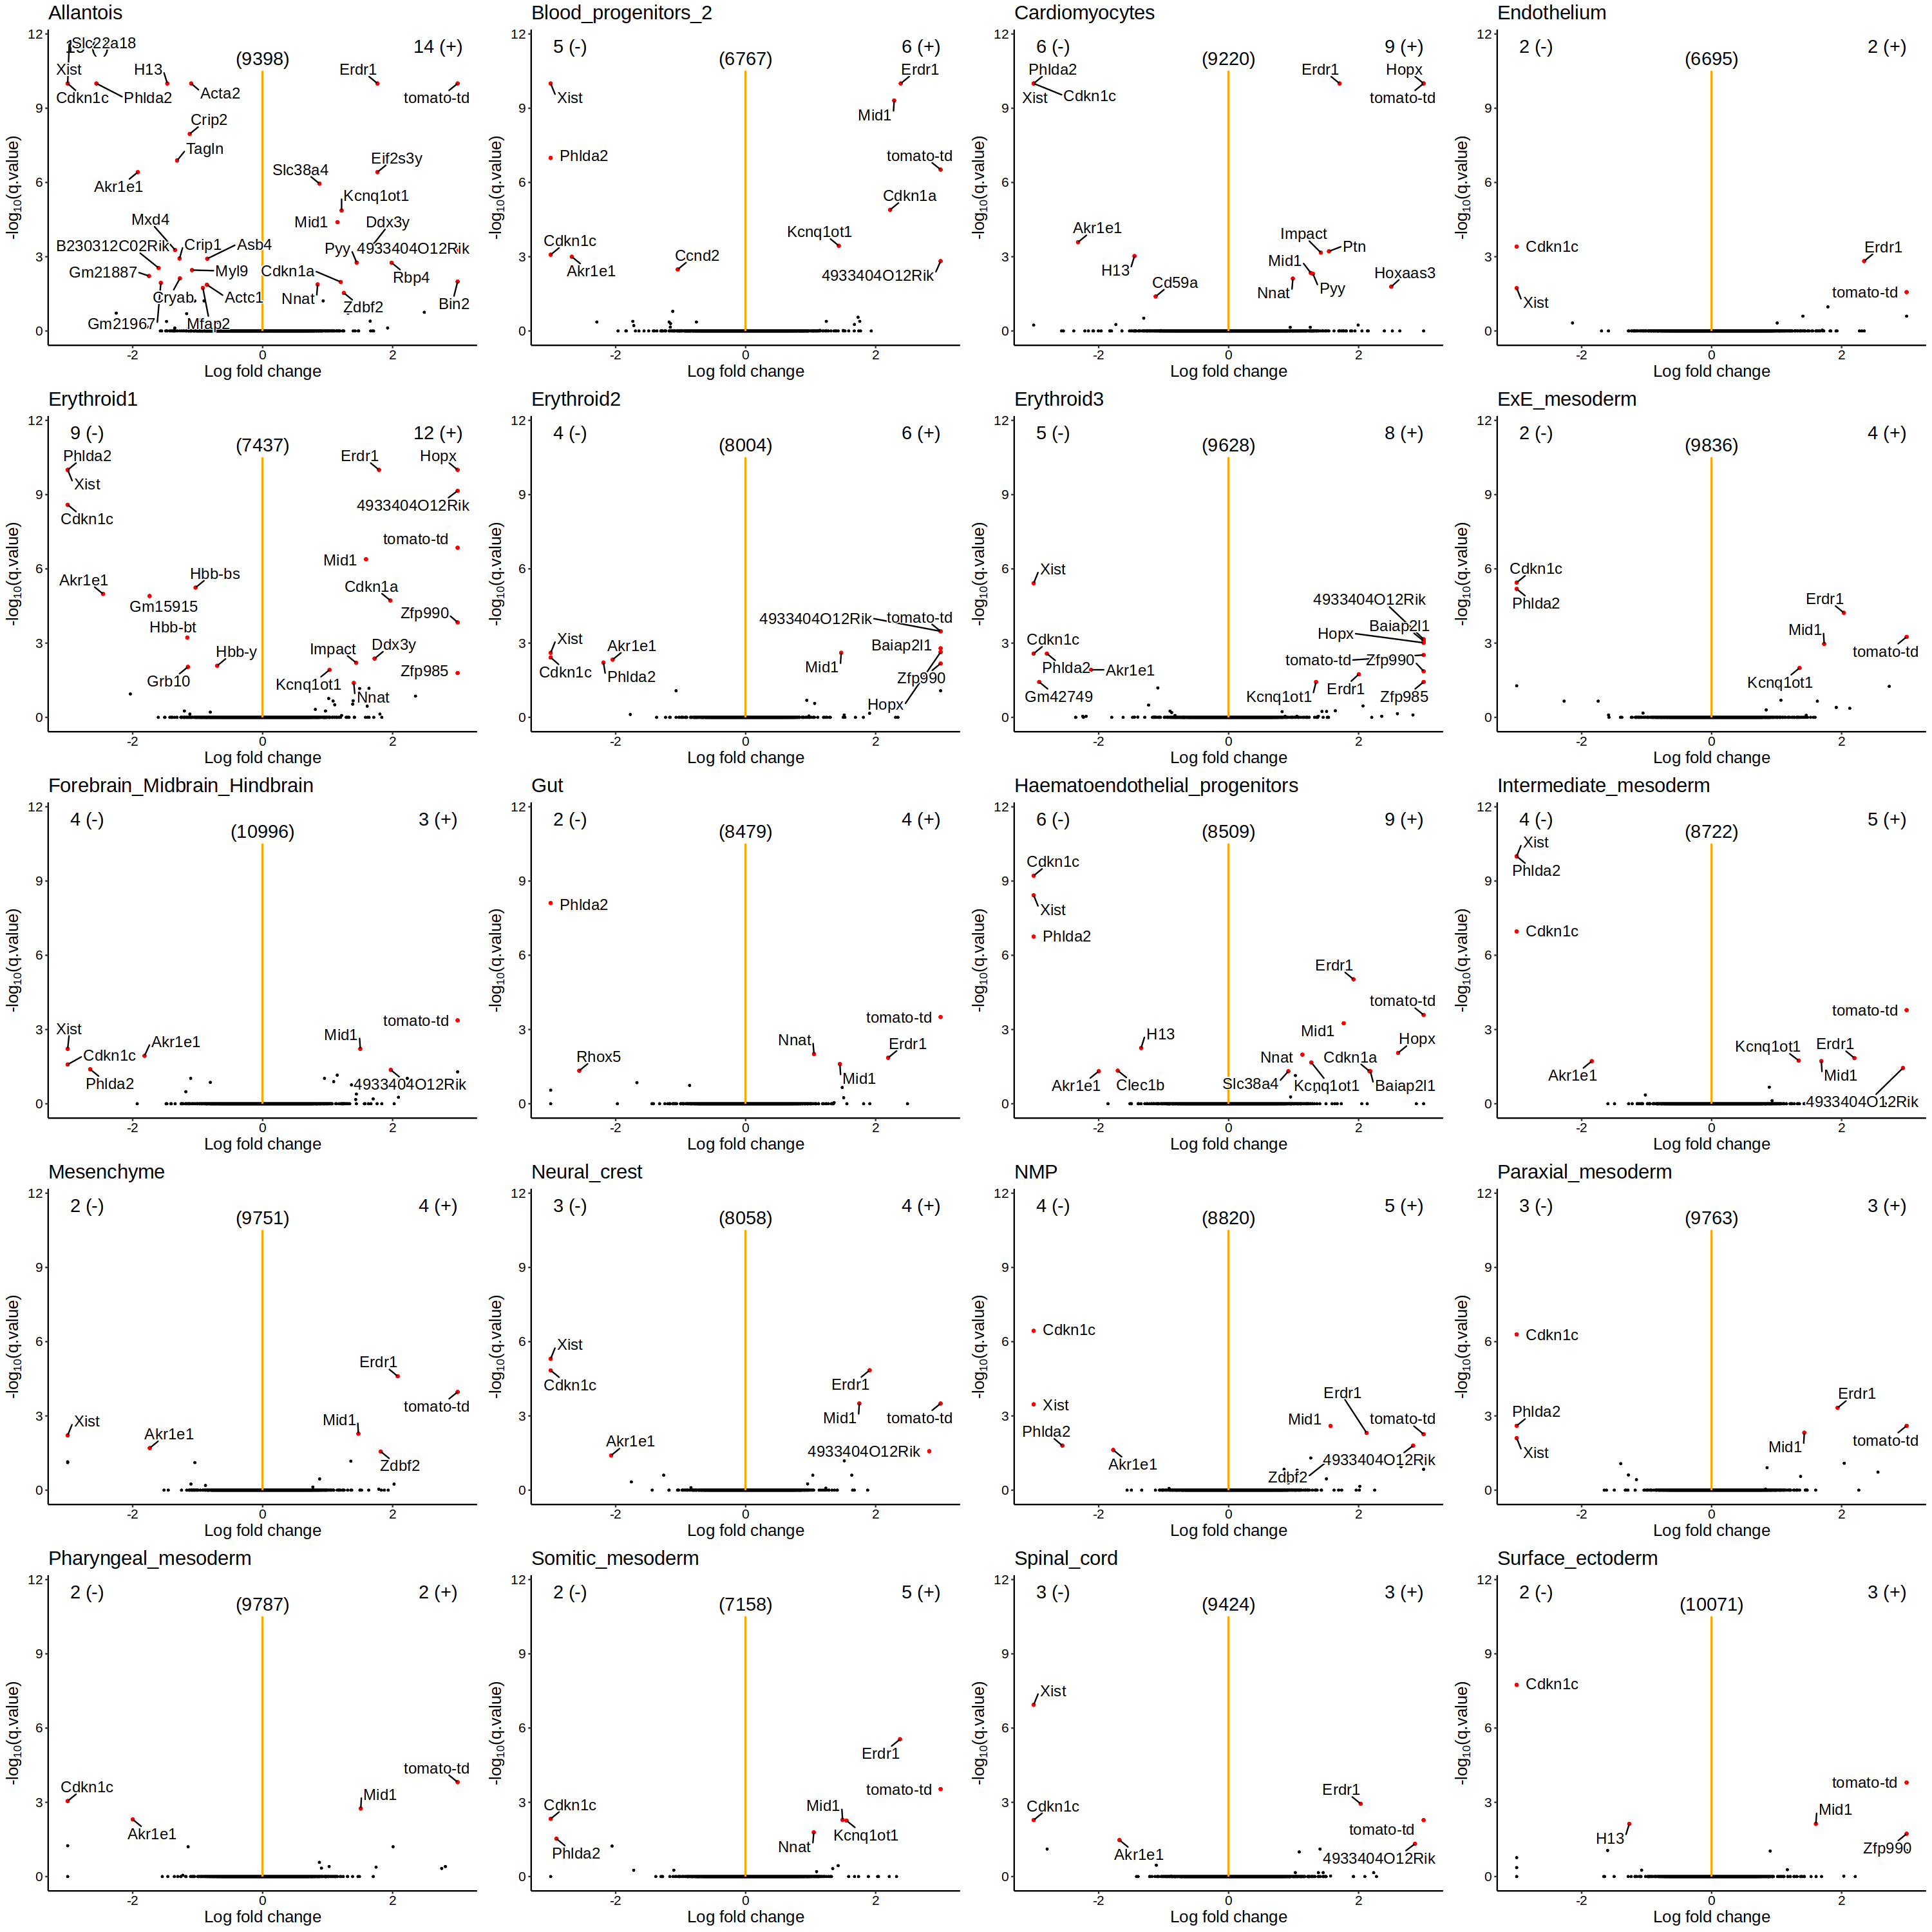

In [21]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

In [134]:
de.results = fread(file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

In [140]:
de.results[gene == 'Hand1']

logFC,unshrunk.logFC,logCPM,PValue,padj_fdr,gene,variable,sig
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>
-0.36605660,-0.36610877,8.241589,0.8336456,1.0000000,Hand1,Allantois,FALSE
0.22686855,0.22715172,6.014704,0.7440915,0.9999996,Hand1,Cardiomyocytes,FALSE
0.32577951,0.32730541,1.391637,0.5201567,1.0000000,Hand1,Erythroid3,FALSE
-0.19813822,-0.19818549,7.300799,0.9579249,1.0000000,Hand1,ExE_mesoderm,FALSE
-0.37575631,-0.37950305,1.417249,0.4657705,0.9999983,Hand1,Forebrain_Midbrain_Hindbrain,FALSE
-0.21986498,-0.22061118,4.298203,0.6650115,1.0000000,Hand1,Haematoendothelial_progenitors,FALSE
0.03351376,0.03351874,6.409711,0.9755972,1.0000000,Hand1,Intermediate_mesoderm,FALSE
-0.16883259,-0.16884037,9.332030,0.9860312,1.0000000,Hand1,Mesenchyme,FALSE
-0.13124583,-0.13143854,4.172732,0.8081513,1.0000000,Hand1,Pharyngeal_mesoderm,FALSE


### Pijuan-Sala WT-injection only

In [141]:
# Create fake pseudobulk replicates for EdgeR 
# use 50% of cells per replicate, for injected and host seperately
sce_in = sce[,sce$sample %in% paste0('sample_', 5:6)]
summed = lapply(1:4, function(x){
    tmp1 = cbind(sce_in[,sce_in$tdTom==TRUE] %>% .[, sample(ncol(.), ncol(.)*0.5)],
                 sce_in[,sce_in$tdTom==FALSE] %>% .[, sample(ncol(.), ncol(.)*0.5)])
    tmp2 <- aggregateAcrossCells(tmp1, 
        id=colData(tmp1)[,c("variable", "sample", "tdTom")])
    tmp2$pool = paste0('pool_', x)
    return(tmp2)
})
summed = do.call('cbind', summed)

In [142]:
summed.filt <- summed[,summed$ncells >= 10]

In [143]:
summed.filt

class: SingleCellExperiment 
dim: 27995 143 
metadata(0):
assays(1): counts
rownames(27995): Xkr4 Gm1992 ... mt-Cytb tomato-td
rowData names(0):
colnames: NULL
colData names(26): sample barcode ... tdTom ncells
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [144]:
table(summed.filt$tdTom, summed.filt$variable)

       
        Allantois Blood_progenitors_2 Cardiomyocytes Endothelium Erythroid1
  FALSE         0                   1              1           4          2
  TRUE          4                   3              4           4          4
       
        Erythroid2 Erythroid3 ExE_mesoderm Forebrain_Midbrain_Hindbrain Gut
  FALSE          4          4            4                            4   4
  TRUE           4          4            4                            4   4
       
        Haematoendothelial_progenitors Intermediate_mesoderm Mesenchyme
  FALSE                              0                     4          4
  TRUE                               4                     4          4
       
        Neural_crest NMP Paraxial_mesoderm Pharyngeal_mesoderm Somitic_mesoderm
  FALSE            4   4                 4                   4                4
  TRUE             4   4                 4                   4                4
       
        Spinal_cord Surface_ectoderm
  FALSE    

In [145]:
table(sce_in$tdTom, sce_in$variable)

       
        Allantois Blood_progenitors_1 Blood_progenitors_2 Cardiomyocytes
  FALSE        13                   4                  13             16
  TRUE         81                   4                  34             80
       
        Caudal_epiblast Caudal_Mesoderm Def._endoderm Endothelium Erythroid1
  FALSE               3               9             5          23         14
  TRUE                0              12             9          71         45
       
        Erythroid2 Erythroid3 ExE_ectoderm ExE_endoderm ExE_mesoderm
  FALSE         39        150            4            4           37
  TRUE          80        230            1            0          154
       
        Forebrain_Midbrain_Hindbrain Gut Haematoendothelial_progenitors
  FALSE                          153  49                             12
  TRUE                           268  53                             65
       
        Intermediate_mesoderm Mesenchyme Neural_crest NMP Notochord
  FALSE            

In [146]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(summed.filt, 
    label=summed.filt$variable,
    design=~tdTom,
    lfc = 0, # had to set this to 1 because otherwise too much is differential in this sample
    coef="tdTomTRUE",
    condition=summed.filt$tdTom
    ) %>% unlist() %>% 
       as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=1 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


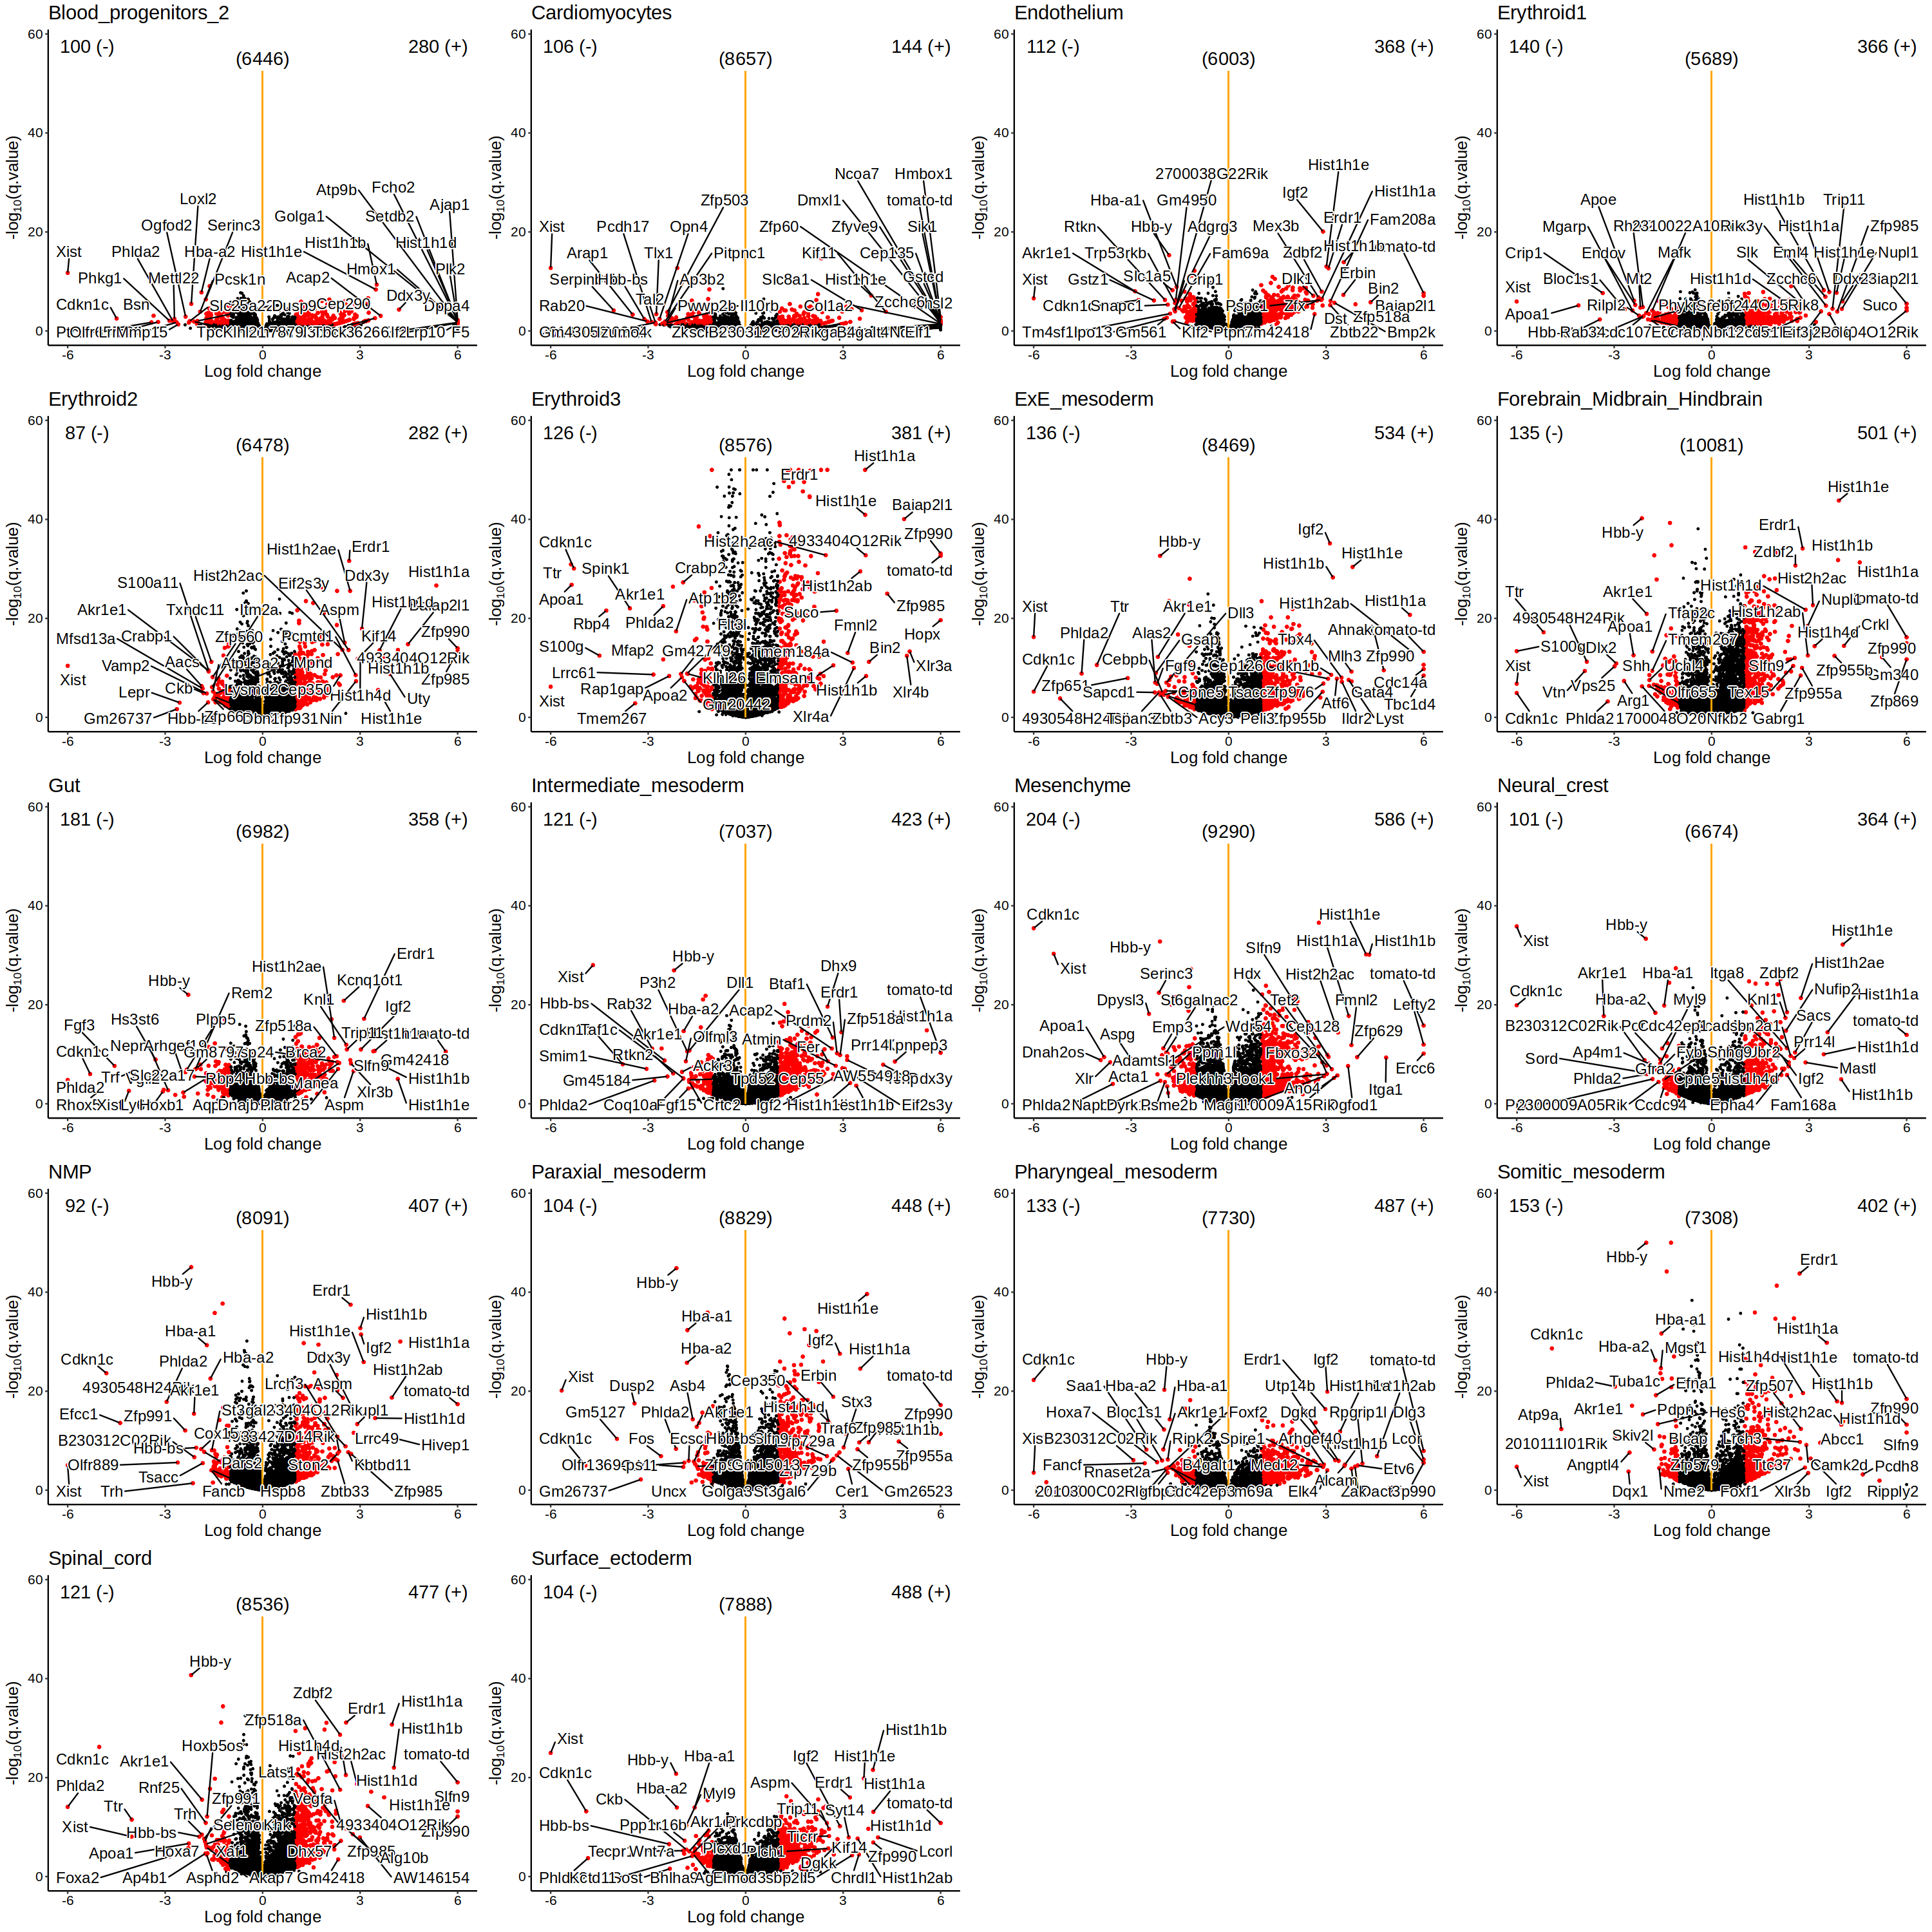

In [147]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=50, xlim=6)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

In [148]:
de.results[gene == 'Hand1']

logFC,logCPM,F,PValue,padj_fdr,gene,variable,sig
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>
1.40593571,5.749880,12.00625712,5.291422e-03,7.832961e-02,Hand1,Cardiomyocytes,FALSE
0.05626624,7.252259,0.63915464,4.586867e-01,5.899192e-01,Hand1,ExE_mesoderm,FALSE
1.38232299,6.965155,9.74489094,1.922833e-02,5.182297e-02,Hand1,Intermediate_mesoderm,FALSE
-0.29094030,9.500046,68.52869276,2.767830e-08,2.715221e-07,Hand1,Mesenchyme,FALSE
0.20073469,4.149260,0.04647046,8.361583e-01,9.009509e-01,Hand1,Pharyngeal_mesoderm,FALSE
2.05946221,3.857118,40.69017552,1.017840e-07,1.182571e-06,Hand1,Somitic_mesoderm,TRUE
0.23621279,7.124474,1.47045454,2.658671e-01,4.003826e-01,Hand1,Surface_ectoderm,FALSE


### Non-Pijuan-Sala WT-injection

In [14]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(sce, 
    id=colData(sce)[,c("variable", "sample", "tdTom")])

In [42]:
summed.filt <- summed[,summed$ncells >= 20 & summed$sample %in% paste0('sample_', 7:10)]

In [43]:
summed.filt

class: SingleCellExperiment 
dim: 27995 89 
metadata(0):
assays(1): counts
rownames(27995): Xkr4 Gm1992 ... mt-Cytb tomato-td
rowData names(0):
colnames: NULL
colData names(26): sample barcode ... tdTom ncells
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [44]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(summed.filt, 
    label=summed.filt$variable,
    design=~factor(pool) + tdTom,
    lfc = 0.5,
    coef="tdTomTRUE",
    condition=summed.filt$tdTom
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


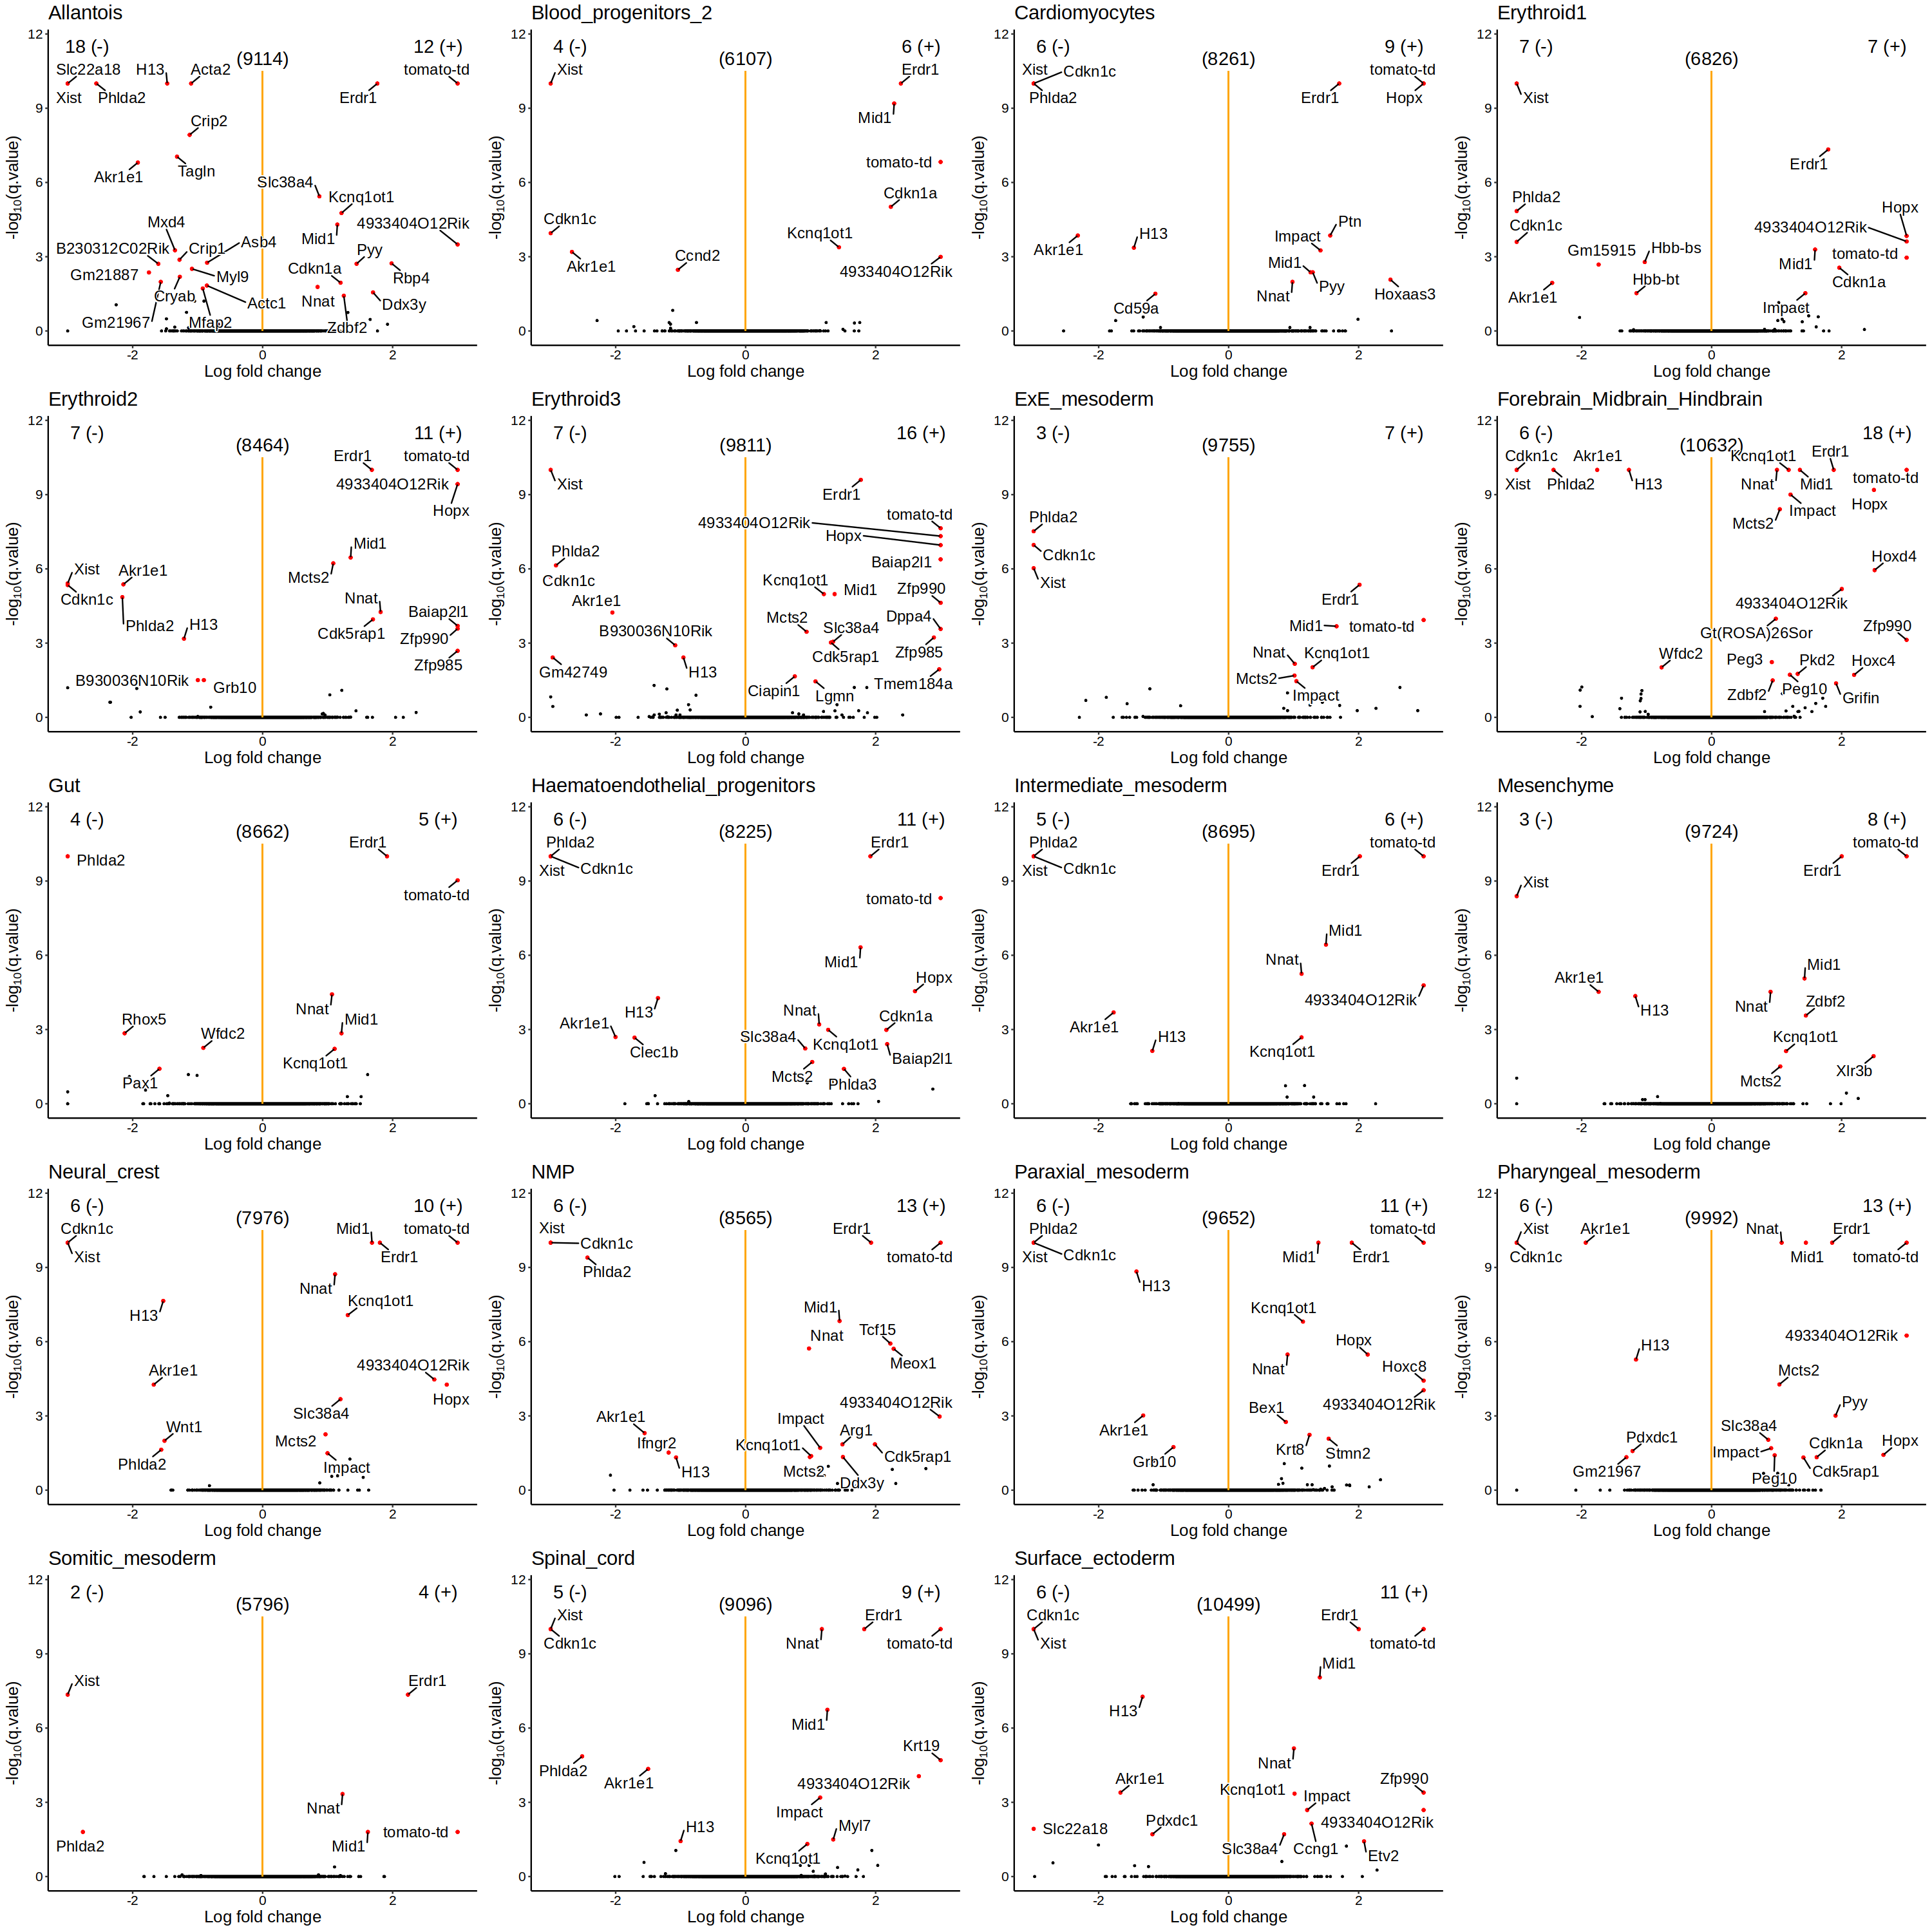

In [45]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

### Test if same wild effect happens as for the first test when using a different pool

More DEGs than before but nothing wild like in the first one

In [115]:
# Create fake pseudobulk replicates for EdgeR 
# use 50% of cells per replicate, for injected and host seperately
sce_in = sce[,sce$sample %in% paste0('sample_', 7:8)]
summed = lapply(1:4, function(x){
    tmp1 = cbind(sce_in[,sce_in$tdTom==TRUE] %>% .[, sample(ncol(.), ncol(.)*0.5)],
                 sce_in[,sce_in$tdTom==FALSE] %>% .[, sample(ncol(.), ncol(.)*0.5)])
    tmp2 <- aggregateAcrossCells(tmp1, 
        id=colData(tmp1)[,c("variable", "sample", "tdTom")])
    tmp2$pool = paste0('pool_', x)
    return(tmp2)
})
summed = do.call('cbind', summed)

In [116]:
summed.filt <- summed[,summed$ncells >= 10]

In [119]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(summed.filt, 
    label=summed.filt$variable,
    design=~tdTom,
    lfc = 0.5,
    coef="tdTomTRUE",
    condition=summed.filt$tdTom
    ) %>% unlist() %>% 
       as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


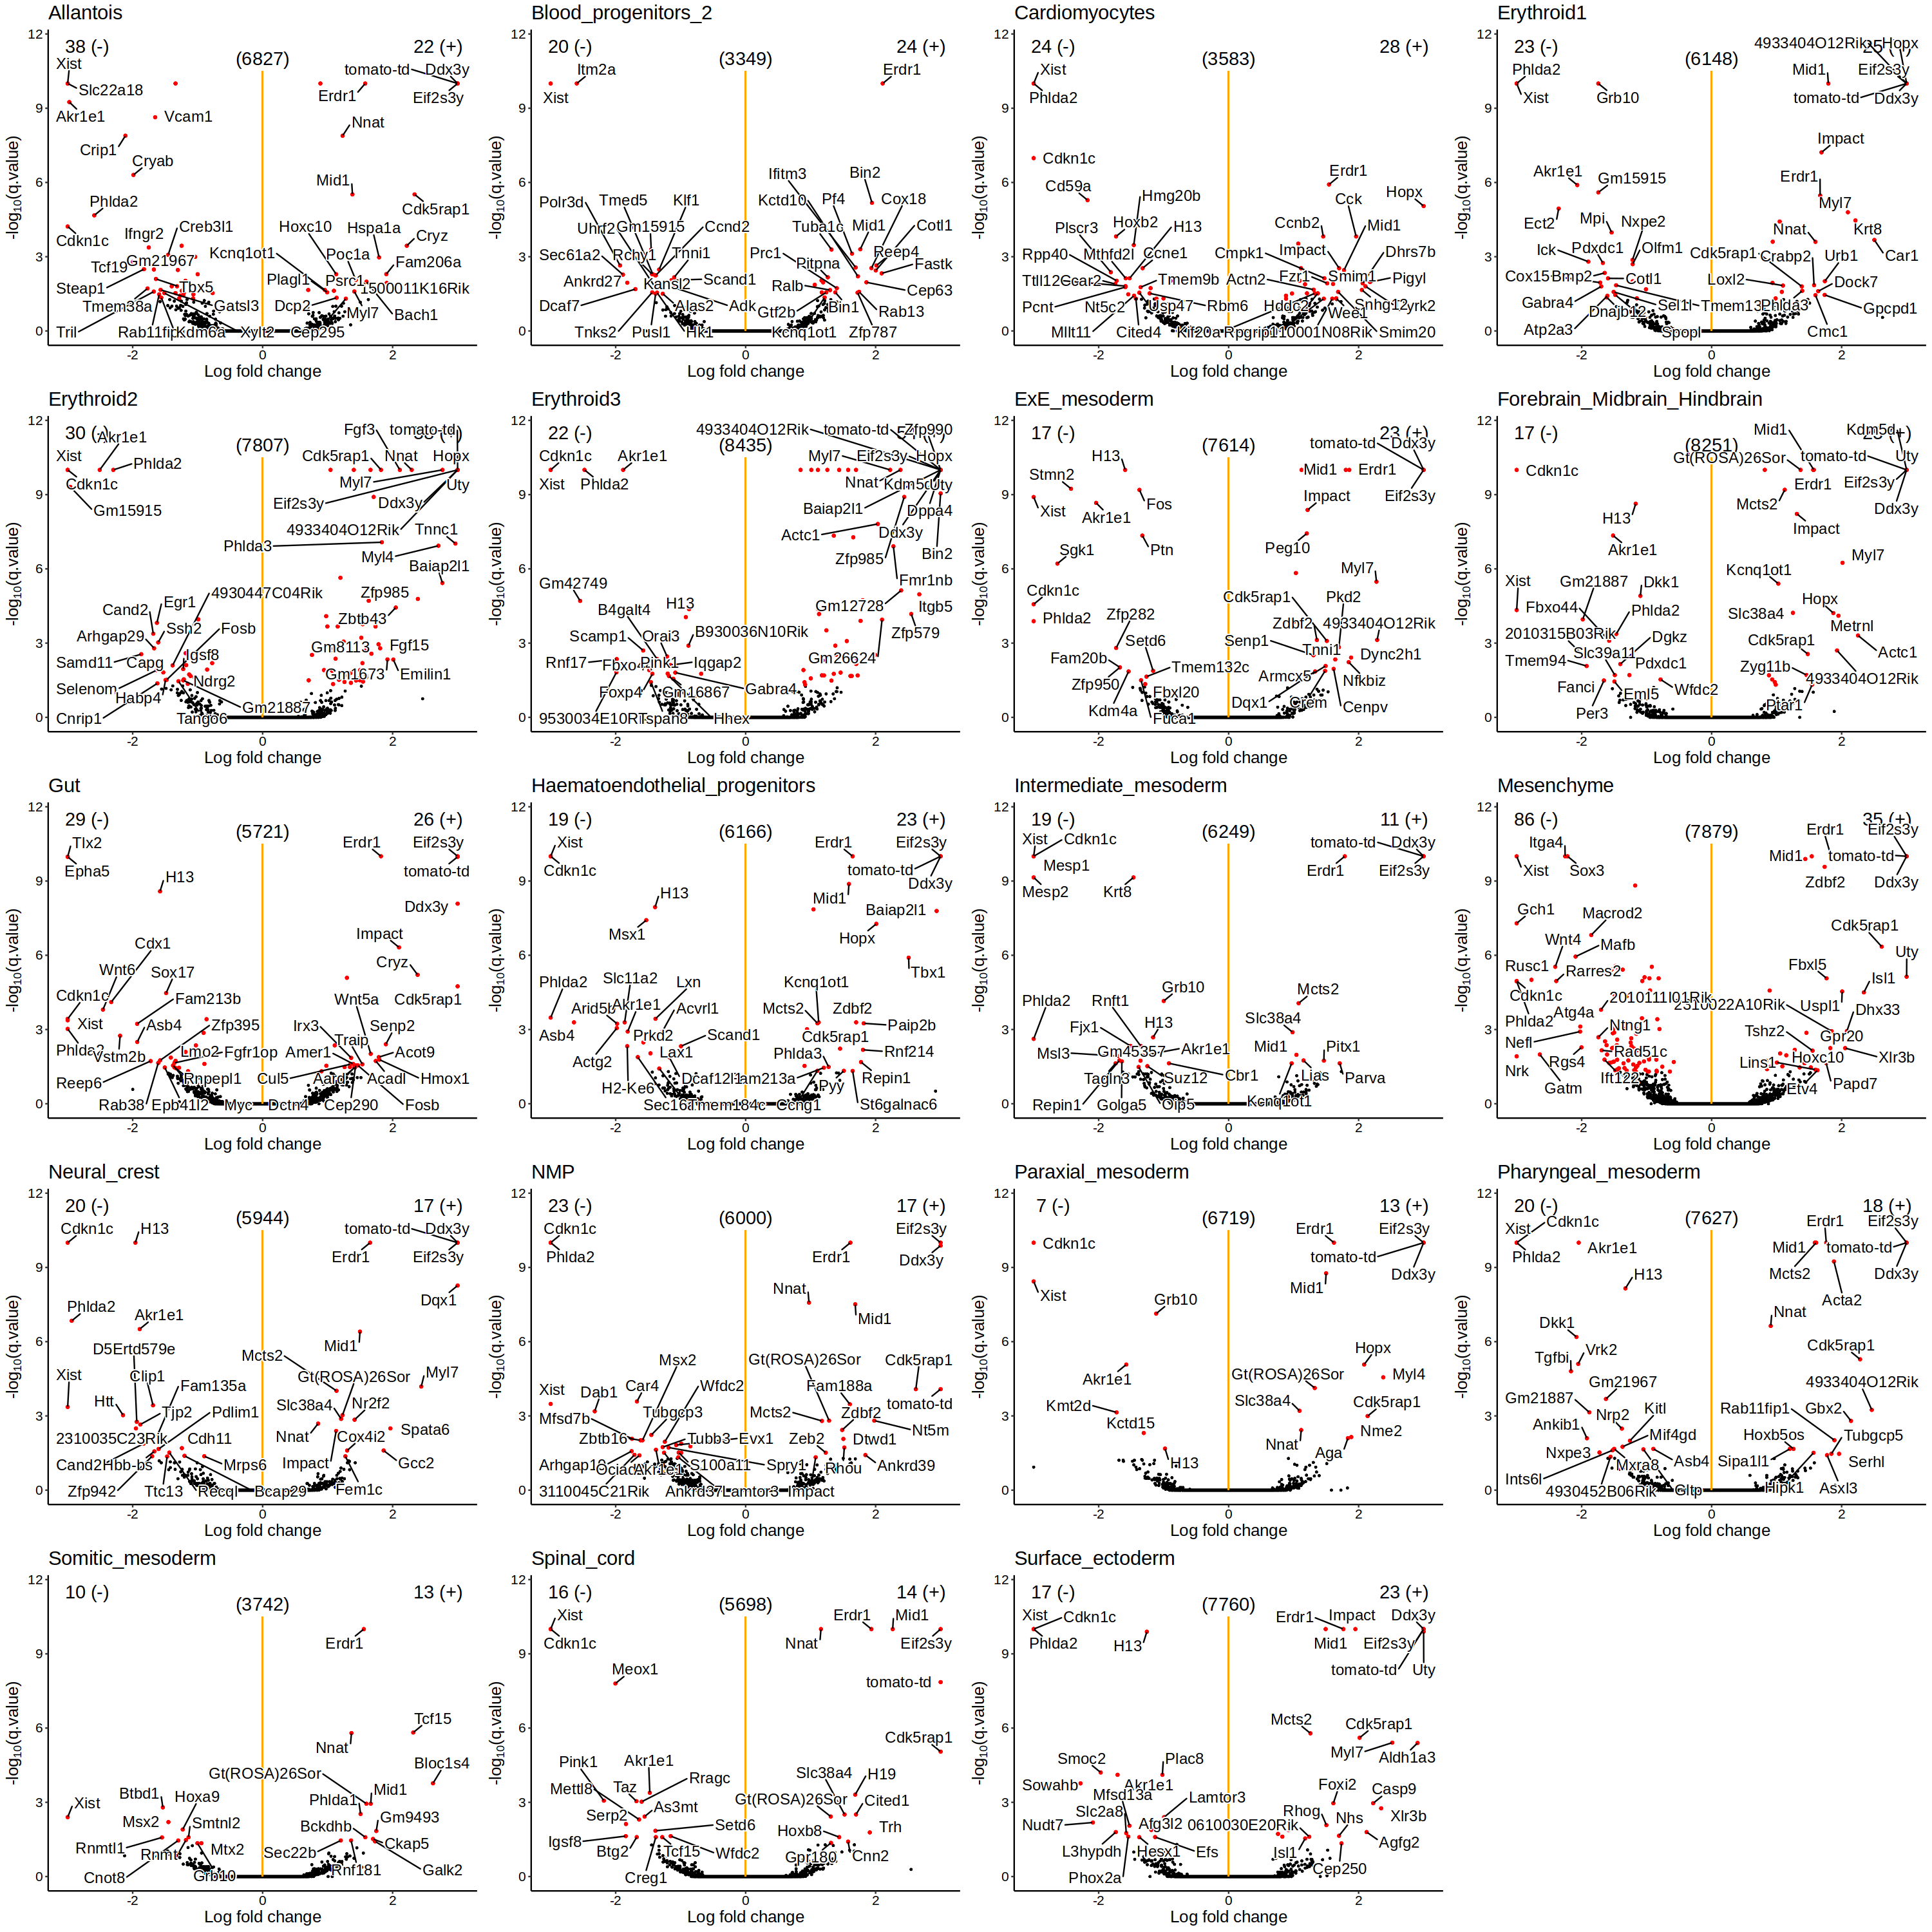

In [120]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot